# ResNet-18 on Residual Autocorrelation with Prompt-Aware Train Sampling

This notebook keeps the residual-autocorrelation representation, but changes the data handling to match the dataset structure more closely:

1. `train` uses prompt-aware grouping from the raw manifest
2. Each training epoch keeps all real images and samples one random AI variant per prompt group
3. `validation` and `test` are treated as flat manifest-driven datasets with no prompt regrouping
4. Labels come from the manifest, not from folder names
5. The image loader works with either nested folders (`split/real/...`, `split/ai_generated/...`) or merged split folders (`split/...`)

This lets training benefit from generator diversity while keeping validation and test faithful to the original fixed splits.


In [1]:
import os
import csv
import random
import time
from pathlib import Path

import matplotlib.pylab as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import wandb
from PIL import Image
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from torchvision.transforms import functional as TF

# Use MPS on Apple Silicon when available, otherwise fall back to CPU.
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(device)


mps


In [2]:
from pathlib import Path
import os

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "requirements.txt").exists() and (PROJECT_ROOT.parent / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "output"

TRAIN_MANIFEST = DATA_ROOT / "metadata" / "train_manifest.csv"
VAL_MANIFEST = DATA_ROOT / "metadata" / "validation_manifest.csv"
TEST_MANIFEST = DATA_ROOT / "metadata" / "test_manifest.csv"

WANDB_ENTITY = "william-em-watson-university-of-calgary-in-alberta"
WANDB_PROJECT = "ai-gen-image-detection"
WANDB_API_KEY = os.getenv("WANDB_API_KEY", "")


In [7]:
# Residual-autocorrelation preprocessing plus manifest-driven loading
image_size = 224
gaussian_kernel_size = 5
gaussian_sigma = 1.0


class EnsureMinSize:
    def __init__(self, min_size=224, interpolation=transforms.InterpolationMode.BILINEAR):
        self.min_size = min_size
        self.interpolation = interpolation

    def __call__(self, image):
        width, height = image.size
        if width >= self.min_size and height >= self.min_size:
            return image

        scale = max(self.min_size / width, self.min_size / height)
        new_width = max(self.min_size, round(width * scale))
        new_height = max(self.min_size, round(height * scale))
        return TF.resize(image, (new_height, new_width), interpolation=self.interpolation)


class ResidualAutocorrelationTransform:
    def __init__(self, image_size=224, gaussian_kernel_size=5, gaussian_sigma=1.0):
        self.image_size = image_size
        self.gaussian_kernel_size = gaussian_kernel_size
        self.gaussian_sigma = gaussian_sigma
        self.ensure_min_size = EnsureMinSize(min_size=image_size)

    def __call__(self, image):
        image = self.ensure_min_size(image)
        gray_image = TF.rgb_to_grayscale(image, num_output_channels=1)
        gray_tensor = TF.to_tensor(gray_image)

        blurred = TF.gaussian_blur(
            gray_tensor,
            kernel_size=[self.gaussian_kernel_size, self.gaussian_kernel_size],
            sigma=[self.gaussian_sigma, self.gaussian_sigma],
        )
        residual = gray_tensor - blurred
        residual = residual - residual.mean()

        residual_2d = residual.squeeze(0)
        spectrum = torch.fft.fft2(residual_2d)
        autocorr = torch.fft.ifft2(spectrum * torch.conj(spectrum)).real
        autocorr = torch.fft.fftshift(autocorr, dim=(-2, -1)).unsqueeze(0)
        autocorr = TF.center_crop(autocorr, [self.image_size, self.image_size])

        autocorr = autocorr - autocorr.amin()
        autocorr = autocorr / (autocorr.amax() + 1e-6)
        autocorr = (autocorr - 0.5) / 0.5
        return autocorr


def resolve_image_path(data_root, row):
    raw_path = Path(data_root) / row["image_path"]
    if raw_path.exists():
        return raw_path

    image_rel_path = Path(row["image_path"])
    split_name = image_rel_path.parts[0]
    merged_path = Path(data_root) / split_name / image_rel_path.name
    if merged_path.exists():
        return merged_path

    raise FileNotFoundError(f"Could not resolve image for row: {row}")


def load_manifest_rows(manifest_path):
    with Path(manifest_path).open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))


def load_prompt_groups(manifest_path):
    rows = load_manifest_rows(manifest_path)
    rows.sort(key=lambda row: int(row["row_index"]))

    groups = []
    start = 0
    while start < len(rows):
        caption = rows[start]["caption"]
        end = start
        while end < len(rows) and rows[end]["caption"] == caption:
            end += 1

        group_rows = rows[start:end]
        groups.append(
            {
                "caption": caption,
                "rows": group_rows,
                "real_rows": [row for row in group_rows if row["label_a"] == "0"],
                "ai_rows": [row for row in group_rows if row["label_a"] == "1"],
            }
        )
        start = end

    return groups


class PromptBalancedResidualTrainDataset(Dataset):
    def __init__(self, manifest_path, data_root, transform, seed=42):
        self.data_root = Path(data_root)
        self.transform = transform
        self.seed = seed
        self.classes = ["ai_generated", "real"]
        self.class_to_idx = {name: idx for idx, name in enumerate(self.classes)}

        self.all_rows = load_manifest_rows(manifest_path)
        self.prompt_groups = load_prompt_groups(manifest_path)
        self.eligible_groups = [
            group for group in self.prompt_groups if group["real_rows"] and group["ai_rows"]
        ]
        self.skipped_groups = len(self.prompt_groups) - len(self.eligible_groups)
        self.records = []
        self.resample_epoch(0)

    def resample_epoch(self, epoch=0):
        rng = random.Random(self.seed + epoch)
        records = []
        for group in self.eligible_groups:
            records.extend(group["real_rows"])
            records.append(rng.choice(group["ai_rows"]))
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        row = self.records[index]
        image = Image.open(resolve_image_path(self.data_root, row)).convert("RGB")
        image = self.transform(image)
        label = self.class_to_idx[row["label_a_name"]]
        return image, label


class ManifestResidualDataset(Dataset):
    def __init__(self, manifest_path, data_root, transform):
        self.data_root = Path(data_root)
        self.transform = transform
        self.records = load_manifest_rows(manifest_path)
        self.classes = ["ai_generated", "real"]
        self.class_to_idx = {name: idx for idx, name in enumerate(self.classes)}

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        row = self.records[index]
        image = Image.open(resolve_image_path(self.data_root, row)).convert("RGB")
        image = self.transform(image)
        label = self.class_to_idx[row["label_a_name"]]
        return image, label


residual_autocorr_transform = ResidualAutocorrelationTransform(
    image_size=image_size,
    gaussian_kernel_size=gaussian_kernel_size,
    gaussian_sigma=gaussian_sigma,
)

train_dataset = PromptBalancedResidualTrainDataset(
    manifest_path=TRAIN_MANIFEST,
    data_root=DATA_ROOT,
    transform=residual_autocorr_transform,
    seed=42,
)
val_dataset = ManifestResidualDataset(
    manifest_path=VAL_MANIFEST,
    data_root=DATA_ROOT,
    transform=residual_autocorr_transform,
)
test_dataset = ManifestResidualDataset(
    manifest_path=TEST_MANIFEST,
    data_root=DATA_ROOT,
    transform=residual_autocorr_transform,
)

batch_size = 32
num_workers = 0

trainloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
valloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
testloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)


In [8]:
class_names = train_dataset.classes
print(class_names)
print("Train manifest rows:", len(train_dataset.all_rows))
print("Train effective epoch size:", len(train_dataset))
print("Train eligible prompt groups:", len(train_dataset.eligible_groups), "| skipped:", train_dataset.skipped_groups)
print("Train real images kept each epoch:", sum(len(group["real_rows"]) for group in train_dataset.eligible_groups))
print("Train AI images sampled each epoch:", len(train_dataset.eligible_groups))
print("Val manifest rows:", len(val_dataset.records))
print("Test manifest rows:", len(test_dataset.records))


['ai_generated', 'real']
Train manifest rows: 14700
Train effective epoch size: 4900
Train eligible prompt groups: 2450 | skipped: 1
Train real images kept each epoch: 2450
Train AI images sampled each epoch: 2450
Val manifest rows: 3100
Test manifest rows: 3500


In [9]:
train_iterator = iter(trainloader)
train_batch = next(train_iterator)

In [10]:
print(train_batch[0].size())
print(train_batch[1].size())

torch.Size([32, 1, 224, 224])
torch.Size([32])


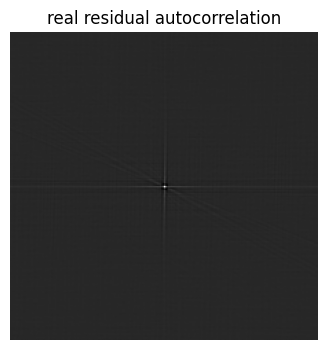

In [11]:
# Visualize one residual-autocorrelation map from the training set.
sample_map = train_batch[0][2].squeeze(0).cpu()
sample_map = (sample_map * 0.5) + 0.5
sample_map = sample_map.clamp(0, 1)

plt.figure(figsize=(4, 4))
plt.imshow(sample_map.numpy(), cmap='gray')
plt.title(f"{class_names[train_batch[1][2].item()]} residual autocorrelation")
plt.axis('off')
plt.show()


In [12]:
class AiGenModel(nn.Module):
    def __init__(self, num_classes=2, use_pretrained=False, freeze_backbone=False):
        super().__init__()

        self.use_pretrained = use_pretrained
        self.freeze_backbone = freeze_backbone

        weights = ResNet18_Weights.DEFAULT if use_pretrained else None
        self.feature_extractor = models.resnet18(weights=weights)

        original_conv = self.feature_extractor.conv1
        self.feature_extractor.conv1 = nn.Conv2d(
            1,
            original_conv.out_channels,
            kernel_size=original_conv.kernel_size,
            stride=original_conv.stride,
            padding=original_conv.padding,
            bias=False,
        )

        if self.use_pretrained:
            with torch.no_grad():
                self.feature_extractor.conv1.weight.copy_(original_conv.weight.mean(dim=1, keepdim=True))

        if self.use_pretrained and self.freeze_backbone:
            for name, param in self.feature_extractor.named_parameters():
                if not name.startswith('fc.'):
                    param.requires_grad = False

        in_features = self.feature_extractor.fc.in_features
        self.feature_extractor.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.feature_extractor(x)


In [13]:
num_classes = len(class_names)
use_pretrained = False
freeze_backbone = False

# The residual-autocorrelation input is single-channel and not RGB-like, so scratch training is the safer default.
net = AiGenModel(
    num_classes=num_classes,
    use_pretrained=use_pretrained,
    freeze_backbone=freeze_backbone,
).to(device)
print(net)


AiGenModel(
  (feature_extractor): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

In [14]:
criterion = nn.CrossEntropyLoss()
learning_rate = 1e-3
weight_decay = 1e-4

trainable_params = [param for param in net.parameters() if param.requires_grad]
optimizer = optim.AdamW(trainable_params, lr=learning_rate, weight_decay=weight_decay)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

input_representation = 'grayscale_noise_residual_autocorrelation'
train_sampling_strategy = 'all_real_plus_one_random_ai_per_prompt_per_epoch'
eval_sampling_strategy = 'flat_manifest_eval_no_prompt_grouping'
path_resolution_strategy = 'manifest_path_first_then_split_basename_for_merged_folders'

if WANDB_API_KEY:
    wandb.login(key=WANDB_API_KEY)
else:
    print('WANDB_API_KEY is not set. Export it in your environment before training if you want W&B logging.')

wandb_config = {
    'train_manifest': str(TRAIN_MANIFEST),
    'val_manifest': str(VAL_MANIFEST),
    'test_manifest': str(TEST_MANIFEST),
    'model_name': 'resnet18',
    'use_pretrained': use_pretrained,
    'freeze_backbone': freeze_backbone,
    'image_size': image_size,
    'gaussian_kernel_size': gaussian_kernel_size,
    'gaussian_sigma': gaussian_sigma,
    'input_representation': input_representation,
    'train_sampling_strategy': train_sampling_strategy,
    'eval_sampling_strategy': eval_sampling_strategy,
    'path_resolution_strategy': path_resolution_strategy,
    'train_eligible_prompt_groups': len(train_dataset.eligible_groups),
    'val_examples': len(val_dataset),
    'test_examples': len(test_dataset),
    'batch_size': batch_size,
    'num_workers': num_workers,
    'learning_rate': learning_rate,
    'weight_decay': weight_decay,
    'num_classes': num_classes,
    'device': str(device),
}

wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    config=wandb_config,
)

wandb.define_metric('epoch')
wandb.define_metric('train_loss', step_metric='epoch')
wandb.define_metric('train_acc', step_metric='epoch')
wandb.define_metric('val_loss', step_metric='epoch')
wandb.define_metric('val_acc', step_metric='epoch')
wandb.define_metric('learning_rate', step_metric='epoch')
wandb.define_metric('epoch_time_sec', step_metric='epoch')
wandb.watch(net, criterion, log='all', log_freq=50)


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/williamwatson/.netrc
wandb: Currently logged in as: william-em-watson (william-em-watson-university-of-calgary-in-alberta) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [15]:
# Tune nepochs and patience depending on how quickly validation loss plateaus.
nepochs = 10
PATH = './genai_resnet18_residual_autocorr_prompt_sampler_best.pth'

wandb.config.update({'nepochs': nepochs}, allow_val_change=True)

best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(nepochs):
    train_dataset.resample_epoch(epoch)

    epoch_start_time = time.perf_counter()
    net.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for inputs, labels in trainloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss = running_train_loss / len(train_dataset)
    train_acc = train_correct / train_total

    net.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for inputs, labels in valloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_dataset)
    val_acc = val_correct / val_total
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    epoch_time_sec = time.perf_counter() - epoch_start_time

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_acc': train_acc,
        'val_loss': val_loss,
        'val_acc': val_acc,
        'learning_rate': current_lr,
        'epoch_time_sec': epoch_time_sec,
    })

    print(
        f'Epoch {epoch + 1}/{nepochs} | '
        f'train_loss={train_loss:.4f} train_acc={train_acc:.4f} | '
        f'val_loss={val_loss:.4f} val_acc={val_acc:.4f}'
    )

    if val_loss < best_val_loss:
        print('Saving best model')
        torch.save(net.state_dict(), PATH)
        best_val_loss = val_loss
        wandb.run.summary['best_val_loss'] = best_val_loss
        wandb.run.summary['best_epoch'] = epoch + 1

print('Finished training')


Epoch 1/10 | train_loss=0.5014 train_acc=0.7645 | val_loss=0.3270 val_acc=0.8723
Saving best model
Epoch 2/10 | train_loss=0.3964 train_acc=0.8231 | val_loss=0.2965 val_acc=0.8894
Saving best model
Epoch 3/10 | train_loss=0.3687 train_acc=0.8367 | val_loss=0.7109 val_acc=0.6810
Epoch 4/10 | train_loss=0.3349 train_acc=0.8567 | val_loss=0.2689 val_acc=0.8926
Saving best model
Epoch 5/10 | train_loss=0.3187 train_acc=0.8629 | val_loss=0.3204 val_acc=0.8565
Epoch 6/10 | train_loss=0.3024 train_acc=0.8769 | val_loss=0.3732 val_acc=0.8161
Epoch 7/10 | train_loss=0.3068 train_acc=0.8712 | val_loss=0.4661 val_acc=0.7761


KeyboardInterrupt: 

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x12ef8c250>> (for post_run_cell), with arguments args (<ExecutionResult object at 13b109f30, execution_count=15 error_before_exec=None error_in_exec= info=<ExecutionInfo object at 13b10bf70, raw_cell="# Tune nepochs and patience depending on how quick.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/williamwatson/meng_winter_courses/codex/genai_classifier_resnet18_residual_autocorr_prompt_train_flat_eval.ipynb#X14sZmlsZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [20]:
# Load the best model before evaluating on the test set.
net = AiGenModel(
    num_classes=len(class_names),
    use_pretrained=use_pretrained,
    freeze_backbone=freeze_backbone,
).to(device)
net.load_state_dict(torch.load(PATH, map_location=device))
net.eval()


Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x12ef8c250>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 13e1dbd60, raw_cell="# Load the best model before evaluating on the tes.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/williamwatson/meng_winter_courses/codex/genai_classifier_resnet18_residual_autocorr_prompt_train_flat_eval.ipynb#X15sZmlsZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

AiGenModel(
  (feature_extractor): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tr

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x12ef8c250>> (for post_run_cell), with arguments args (<ExecutionResult object at 13e1dbdf0, execution_count=20 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 13e1dbd60, raw_cell="# Load the best model before evaluating on the tes.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/williamwatson/meng_winter_courses/codex/genai_classifier_resnet18_residual_autocorr_prompt_train_flat_eval.ipynb#X15sZmlsZQ%3D%3D> result=AiGenModel(
  (feature_extractor): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (con

ConnectionResetError: Connection lost

In [21]:
correct = 0
total = 0
test_loss = 0.0

test_start_time = time.perf_counter()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = net(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_inference_time_sec = time.perf_counter() - test_start_time
test_loss = test_loss / len(test_dataset)
test_accuracy = correct / total

test_metrics = {
    'test_loss': test_loss,
    'test_accuracy': test_accuracy,
    'test_accuracy_percent': 100 * test_accuracy,
    'test_inference_time_sec': test_inference_time_sec,
}
# wandb.log(test_metrics)
# for key, value in test_metrics.items():
#     wandb.run.summary[key] = value

print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {100 * test_accuracy:.2f}%')
print(f'Test inference time: {test_inference_time_sec:.2f}s')



Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x12ef8c250>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 169305990, raw_cell="correct = 0
total = 0
test_loss = 0.0

test_start_.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/williamwatson/meng_winter_courses/codex/genai_classifier_resnet18_residual_autocorr_prompt_train_flat_eval.ipynb#X16sZmlsZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

Test loss: 0.7760
Test accuracy: 74.00%
Test inference time: 123.73s
Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x12ef8c250>> (for post_run_cell), with arguments args (<ExecutionResult object at 169305a50, execution_count=21 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 169305990, raw_cell="correct = 0
total = 0
test_loss = 0.0

test_start_.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/williamwatson/meng_winter_courses/codex/genai_classifier_resnet18_residual_autocorr_prompt_train_flat_eval.ipynb#X16sZmlsZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [22]:
# Optional: per-class accuracy helps us see whether one class is being ignored.
class_correct = {name: 0 for name in class_names}
class_total = {name: 0 for name in class_names}

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)

        for label, pred in zip(labels, predicted):
            class_name = class_names[label.item()]
            class_total[class_name] += 1
            if label.item() == pred.item():
                class_correct[class_name] += 1

for class_name in class_names:
    accuracy = class_correct[class_name] / max(class_total[class_name], 1)
    print(f'{class_name}: {100 * accuracy:.2f}% ({class_correct[class_name]}/{class_total[class_name]})')
    wandb.log({f'test_accuracy_{class_name}': accuracy})
    wandb.run.summary[f'test_accuracy_{class_name}'] = accuracy



Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x12ef8c250>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 176a387f0, raw_cell="# Optional: per-class accuracy helps us see whethe.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/williamwatson/meng_winter_courses/codex/genai_classifier_resnet18_residual_autocorr_prompt_train_flat_eval.ipynb#X20sZmlsZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

ai_generated: 81.59% (2358/2890)


ConnectionResetError: Connection lost

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x12ef8c250>> (for post_run_cell), with arguments args (<ExecutionResult object at 176a17d90, execution_count=22 error_before_exec=None error_in_exec=Connection lost info=<ExecutionInfo object at 176a387f0, raw_cell="# Optional: per-class accuracy helps us see whethe.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/williamwatson/meng_winter_courses/codex/genai_classifier_resnet18_residual_autocorr_prompt_train_flat_eval.ipynb#X20sZmlsZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x12ef8c250>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 13e2874c0, raw_cell="# Optional: visualize training curves.
plt.figure(.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/williamwatson/meng_winter_courses/codex/genai_classifier_resnet18_residual_autocorr_prompt_train_flat_eval.ipynb#X21sZmlsZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

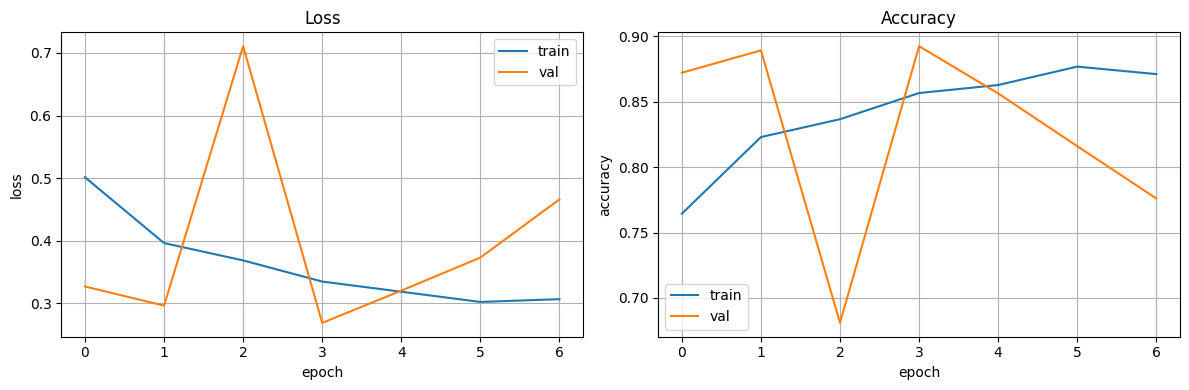

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x12ef8c250>> (for post_run_cell), with arguments args (<ExecutionResult object at 13e287e20, execution_count=23 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 13e2874c0, raw_cell="# Optional: visualize training curves.
plt.figure(.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/williamwatson/meng_winter_courses/codex/genai_classifier_resnet18_residual_autocorr_prompt_train_flat_eval.ipynb#X21sZmlsZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [23]:
# Optional: visualize training curves.
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.title('Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='train')
plt.plot(history['val_acc'], label='val')
plt.title('Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# W&B already turns the logged epoch metrics into charts automatically.



Error in callback <bound method _WandbInit._pre_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x12ef8c250>> (for pre_run_cell), with arguments args (<ExecutionInfo object at 1687df7c0, raw_cell="# Optional: plot the test-set confusion matrix.
co.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/williamwatson/meng_winter_courses/codex/genai_classifier_resnet18_residual_autocorr_prompt_train_flat_eval.ipynb#X22sZmlsZQ%3D%3D>,),kwargs {}:


ConnectionResetError: Connection lost

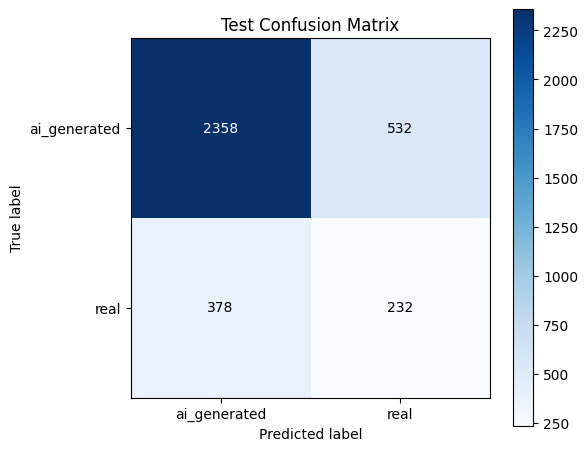

ConnectionResetError: Connection lost

Error in callback <bound method _WandbInit._post_run_cell_hook of <wandb.sdk.wandb_init._WandbInit object at 0x12ef8c250>> (for post_run_cell), with arguments args (<ExecutionResult object at 17a69a620, execution_count=24 error_before_exec=None error_in_exec=Connection lost info=<ExecutionInfo object at 1687df7c0, raw_cell="# Optional: plot the test-set confusion matrix.
co.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/williamwatson/meng_winter_courses/codex/genai_classifier_resnet18_residual_autocorr_prompt_train_flat_eval.ipynb#X22sZmlsZQ%3D%3D> result=None>,),kwargs {}:


ConnectionResetError: Connection lost

In [24]:
# Optional: plot the test-set confusion matrix.
confusion_matrix = torch.zeros((len(class_names), len(class_names)), dtype=torch.int64)

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)

        for label, pred in zip(labels.view(-1), predicted.view(-1)):
            confusion_matrix[label.item(), pred.item()] += 1

cm = confusion_matrix.cpu().numpy()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)

ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names)
ax.set_yticklabels(class_names)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_title('Test Confusion Matrix')

threshold = cm.max() / 2 if cm.size else 0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center',
            color='white' if cm[i, j] > threshold else 'black',
        )

plt.tight_layout()
plt.show()

wandb.finish()
